In [147]:
import pandas as pd
import numpy as np


In [148]:
exp=np.array([[1.1,1.3,1.5,2.0,2.2]]).reshape(-1,1)
salary=np.array([[39343,46205,37731,43525,39891]]).reshape(-1,1)



In [149]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

In [150]:
lr.fit(exp,salary)

LinearRegression()

In [151]:
lr.predict([[2.5]])

array([[41242.28110599]])

In [152]:
lr.coef_

array([[-109.9078341]])

In [153]:
lr.intercept_

array([41517.05069124])

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
df=pd.read_csv(r"C:\Users\CM617YH\OneDrive - EY\Desktop\study\data\Housing.csv")

In [156]:
#data cleaning

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [157]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [158]:
df.shape

(545, 13)

In [159]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [160]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


C:\Users\CM617YH\AppData\Local\Temp\ipykernel_61000\3819986719.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df.price)


np.float64(1.2122388370279802)

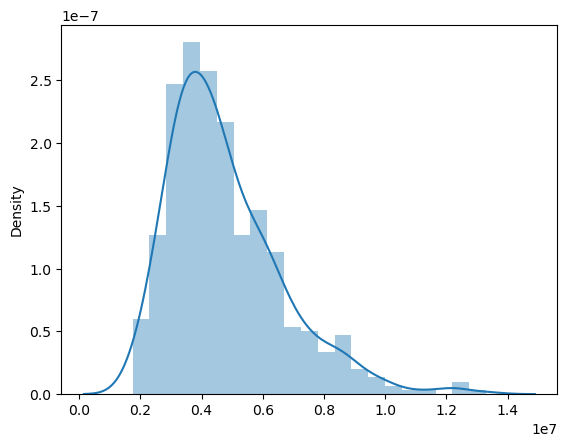

In [163]:
sns.distplot(x=df.price)
df.price.skew()

<Axes: ylabel='price'>

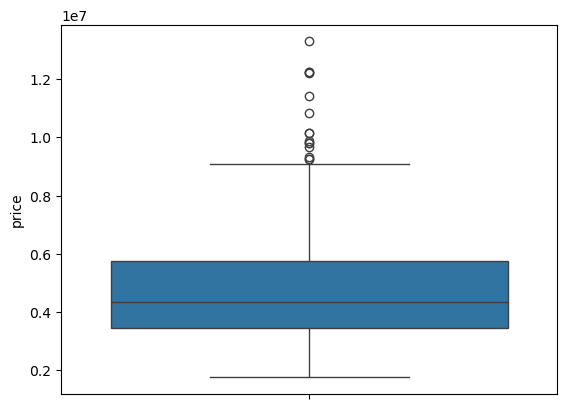

In [164]:
sns.boxplot(df.price)

In [165]:
df.select_dtypes(include="object")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [166]:
# from sklearn.preprocessing import OneHotEncoder
# oh=OneHotEncoder(sparse_output=True,drop="first")
# x_train_encode=oh.fit_transform(x_train.select_dtypes(include="object")).toarray()
# x_train_encode
# df.select_dtypes(include="object").columns
# df.drop(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
#        'airconditioning', 'prefarea', 'furnishingstatus'],axis=1,inplace=True)
# oh.transform(x_test.select_dtypes(include="object")).toarray()

In [172]:
df=pd.get_dummies(df,df.select_dtypes(include="object").columns,drop_first=True,dtype=int)

In [173]:
x=df.drop("price",axis=1)
y=df.price


In [174]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=51)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(436, 13)
(436,)
(109, 13)
(109,)


In [175]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [176]:
lr.fit(x_train,y_train)

LinearRegression()

In [177]:
lr.coef_

array([ 2.20570762e+02,  1.34958698e+05,  9.34027617e+05,  4.69026885e+05,
        2.48001762e+05,  4.94995665e+05,  3.23139774e+05,  2.98351727e+05,
        1.15390993e+06,  8.89132560e+05,  6.74786669e+05, -9.55893377e+04,
       -4.83006921e+05])

In [178]:
lr.intercept_

np.float64(169771.42906307336)

In [180]:
pred=lr.predict(x_test)

In [181]:
from sklearn.metrics import mean_squared_error,r2_score

In [182]:
print(mean_squared_error(y_test,pred))

895553579096.2848


In [183]:
print(r2_score(y_test,pred))

0.7014314531352568


<Axes: xlabel='price'>

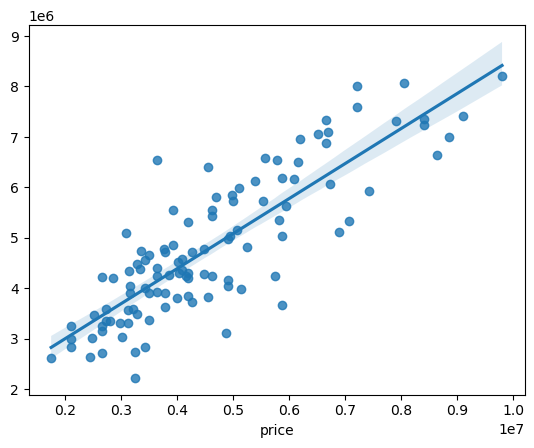

In [185]:
sns.regplot(x=y_test,y=pred)

In [189]:
x_test.head(1).values

array([[2856,    3,    1,    3,    0,    1,    0,    0,    0,    0,    1,
           0,    0]])

In [196]:
price=lr.predict([[2856,    3,    1,    3,    0,    1,    0,    0,    0,    0,    1,
           0,    0]])

print(f"Your expected house price is  rs.{price}")

Your expected house price is  rs.[4715488.22408604]


C:\Users\CM617YH\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [197]:
from sklearn.linear_model import SGDRegressor

In [214]:
sgd=SGDRegressor(alpha=0.000001)

In [215]:
sgd.fit(x_train,y_train)

SGDRegressor(alpha=1e-06)

In [216]:
pred1=sgd.predict(x_test)

In [217]:
print(mean_squared_error(y_test,pred1))
print(r2_score(y_test,pred1))

1.2365900436719546e+32


In [218]:
print(r2_score(y_test,pred1))

-4.122666706096093e+19


In [219]:
from sklearn.linear_model import Ridge,Lasso

In [220]:
re=Ridge()

In [222]:
re.fit(x_train,y_train)

Ridge()

In [224]:
pred2=re.predict(x_test)

In [225]:
print(mean_squared_error(y_test,pred2))
print(r2_score(y_test,pred2))

886273343053.1018
0.7045253903989224


In [226]:
la=Lasso()
la.fit(x_train,y_train)
pred2=la.predict(x_test)
print(mean_squared_error(y_test,pred2))
print(r2_score(y_test,pred2))

895548612727.7045
0.7014331088725403
